# 3D visualization in dynamo

dynamo v1.4 ships a full suite of **3D visualizations** built on matplotlib, Plotly and PyVista:

| function | what it draws | backends |
|---|---|---|
| `dyn.pl.scatters_interactive` | interactive 3D scatter | Plotly, PyVista |
| `dyn.pl.cell_wise_vectors_3d` | per-cell velocity vectors | matplotlib, PyVista |
| `dyn.pl.topography_3D` | vector-field topography (fixed points) | matplotlib, PyVista |
| `dyn.pl.plot_3d_streamtube` | fate streamtubes | Plotly |
| `dyn.mv.PyvistaAnim` | 3D fate animation | PyVista |

We use the **pancreatic endocrinogenesis** dataset, whose differentiation trajectory is well established (Ductal → Ngn3 low EP → Ngn3 high EP → Pre-endocrine → the endocrine fates Alpha / Beta / Delta / Epsilon). That known direction lets us **sanity-check the 3D velocity arrows against the 2D flow**. Static (matplotlib) and Plotly plots render inline; the PyVista/animation calls are shown as code to run locally.

In [1]:
import warnings
warnings.filterwarnings('ignore')

from IPython.display import HTML, display
import dynamo as dyn
dyn.configuration.set_figure_params('dynamo', background='white')

def show_plotly(fig):
    """Embed a Plotly figure inline (interactive) so it renders in the static notebook."""
    display(HTML(fig.to_html(include_plotlyjs='cdn', full_html=False)))

## 1. Preprocess and estimate velocity

Load the pancreas dataset and run the standard dynamo workflow (preprocess → `dynamics`).

In [2]:
adata = dyn.sample_data.pancreatic_endocrinogenesis()
celltype_key = 'clusters'

preprocessor = dyn.pp.Preprocessor()
preprocessor.preprocess_adata(adata, recipe='monocle')
dyn.tl.dynamics(adata, model='stochastic', cores=4)
adata

|-----> Downloading data to ./data/endocrinogenesis_day15.h5ad


|-----> in progress: 1.0147%

|-----> in progress: 2.0293%

|-----> in progress: 3.0440%

|-----> in progress: 4.0587%

...

|-----------> making adata smooth...


|-----> calculating first/second moments...


|-----> [moments calculation] completed [24.3643s]



╭─ SUMMARY: dynamics ────────────────────────────────────────────────╮
│  Duration: 30.6026s                                                │
│  Shape:    3,696 x 27,998 (Unchanged)                              │
│                                                                    │
│  CHANGES DETECTED                                                  │
│  ────────────────                                                  │
│  ● VAR    │ ✚ use_for_dynamics (bool)                              │
│                                                                    │
│  ● UNS    │ ✚ dynamics                                             │
│           │ ✚ vel_params_names                                     │
│                                                                    │
│  ● OBSP   │ ✚ moments_con (sparse matrix, 3696x3696)               │
│                                                                    │
│  ● LAYERS │ ✚ M_s (sparse matrix, 3696x27998)                      │
│    

AnnData object with n_obs × n_vars = 3696 × 27998
    obs: 'clusters_coarse', 'clusters', 'S_score', 'G2M_score', 'nGenes', 'nCounts', 'pMito', 'pass_basic_filter', 'Size_Factor', 'initial_cell_size', 'spliced_Size_Factor', 'initial_spliced_cell_size', 'unspliced_Size_Factor', 'initial_unspliced_cell_size', 'ntr'
    var: 'highly_variable_genes', 'nCells', 'nCounts', 'pass_basic_filter', 'log_cv', 'score', 'log_m', 'frac', 'use_for_pca', 'ntr', 'use_for_dynamics'
    uns: 'clusters_coarse_colors', 'clusters_colors', 'day_colors', 'neighbors', 'pca', 'pp', 'velocyto_SVR', 'feature_selection', 'PCs', 'explained_variance_ratio_', 'pca_mean', 'history_log', 'vel_params_names', 'dynamics'
    obsm: 'X_pca', 'X_umap'
    varm: 'vel_params'
    layers: 'spliced', 'unspliced', 'X_spliced', 'X_unspliced', 'M_u', 'M_uu', 'M_s', 'M_us', 'M_ss', 'velocity_S'
    obsp: 'distances', 'connectivities', 'moments_con'

## 2. 2D reference flow

First, the familiar **2D** velocity streamlines. The flow runs from Ductal/Ngn3 progenitors into the Pre-endocrine and terminal endocrine states — this is the ground truth we will compare the 3D arrows against.

|-----> retrieve data for non-linear dimension reduction...


|-----> [UMAP] using X_umap with n_pca_components = 30


|-----> <insert> X_umap to obsm in AnnData Object.


|-----> [UMAP] completed [21.3198s]



╭─ SUMMARY: reduceDimension ─────────────────────────────────────────╮
│  Duration: 21.3214s                                                │
│  Shape:    3,696 x 27,998 (Unchanged)                              │
│                                                                    │
│  CHANGES DETECTED                                                  │
│  ────────────────                                                  │
│  ● UNS    │ ✚ umap_fit                                             │
│                                                                    │
╰────────────────────────────────────────────────────────────────────╯
|-----? Some row sums(out degree) in adata's neighbor graph are zero.


...

|-----------> method kd_tree selected



╭─ SUMMARY: cell_velocities ─────────────────────────────────────────╮
│  Duration: 4.1745s                                                 │
│  Shape:    3,696 x 27,998 (Unchanged)                              │
│                                                                    │
│  CHANGES DETECTED                                                  │
│  ────────────────                                                  │
│  ● VAR    │ ✚ use_for_transition (bool)                            │
│                                                                    │
│  ● UNS    │ ✚ grid_velocity_umap                                   │
│                                                                    │
│  ● OBSP   │ ✚ pearson_transition_matrix (sparse matrix, 3696x3696) │
│                                                                    │
│  ● OBSM   │ ✚ velocity_umap (array, 3696x2)                        │
│                                                                    │
╰────

|-----------> method kd_tree selected


|-----------> plotting with basis key=X_umap


|-----------> skip filtering clusters by stack threshold when stacking color because it is not a numeric type


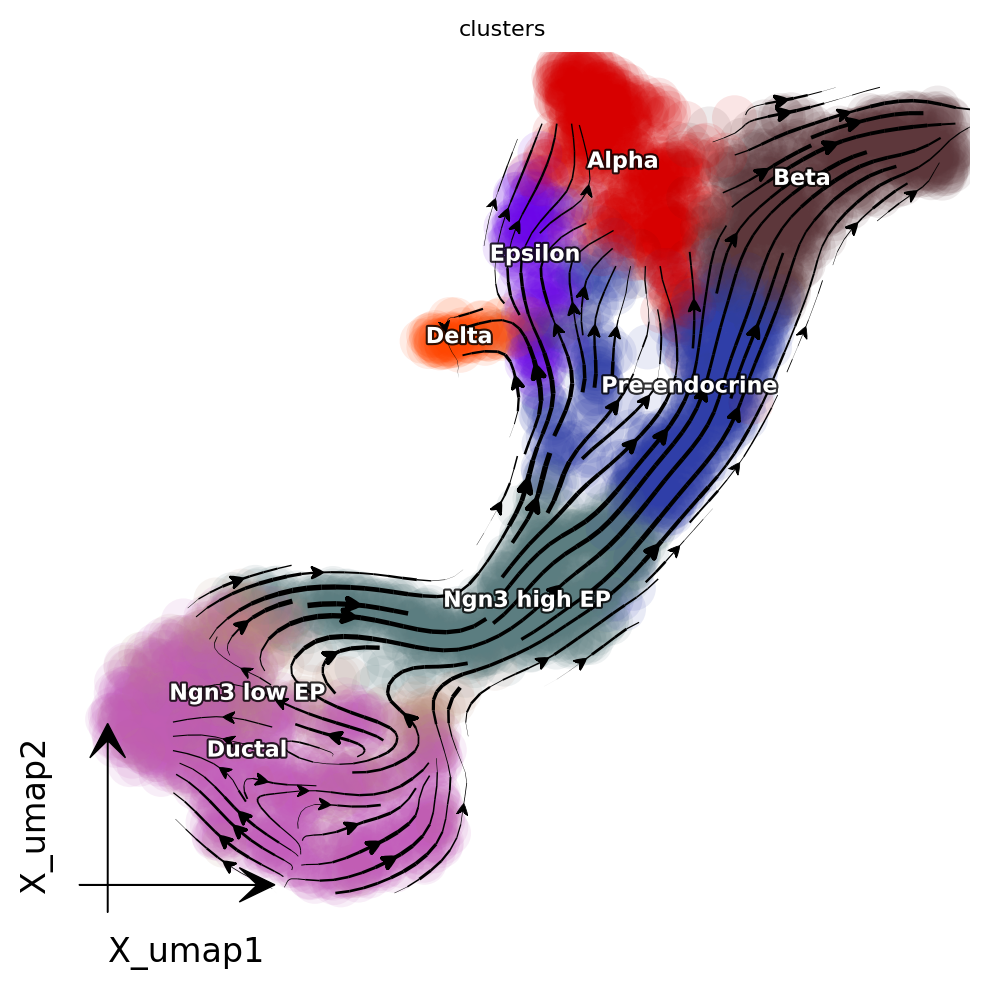

In [3]:
dyn.tl.reduceDimension(adata, basis='umap', n_components=2, enforce=True)
dyn.tl.cell_velocities(adata, basis='umap')
dyn.pl.streamline_plot(adata, color=[celltype_key], basis='umap', figsize=(5, 5))

## 3. Build a 3D embedding

Now compute a **3-component** UMAP and project velocities onto it (`cell_velocities`). The cells below render this 3D field several ways.

In [4]:
dyn.tl.reduceDimension(adata, basis='umap', n_components=3, enforce=True)
dyn.tl.cell_velocities(adata, basis='umap')
print('X_umap:', adata.obsm['X_umap'].shape, '| velocity_umap:', adata.obsm['velocity_umap'].shape)

|-----> retrieve data for non-linear dimension reduction...


|-----> [UMAP] using X_umap with n_pca_components = 30


|-----> <insert> X_umap to obsm in AnnData Object.


|-----> [UMAP] completed [17.7392s]



╭─ SUMMARY: reduceDimension ─────────────────────────────────────────╮
│  Duration: 17.7407s                                                │
│  Shape:    3,696 x 27,998 (Unchanged)                              │
│                                                                    │
│  CHANGES DETECTED                                                  │
│  ────────────────                                                  │
╰────────────────────────────────────────────────────────────────────╯


...

|-----> [projecting velocity vector to low dimensional embedding] completed [0.3989s]


|-----> method arg is None, choosing methods automatically...


|-----------> method kd_tree selected



╭─ SUMMARY: cell_velocities ─────────────────────────────────────────╮


│  Duration: 0.6435s                                                 │
│  Shape:    3,696 x 27,998 (Unchanged)                              │
│                                                                    │
│  CHANGES DETECTED                                                  │
│  ────────────────                                                  │
╰────────────────────────────────────────────────────────────────────╯
X_umap: (3696, 3) | velocity_umap: (3696, 3)


## 4. Interactive 3D scatter — `scatters_interactive`

`dyn.pl.scatters_interactive` draws an interactive 3D scatter. With `plot_method='plotly'` it returns a Plotly figure you can rotate and zoom; here we embed it inline. (Use `plot_method='pv'` for a PyVista window locally.)

|-----------> plotting with basis key=X_umap


|-----------> skip filtering clusters by stack threshold when stacking color because it is not a numeric type


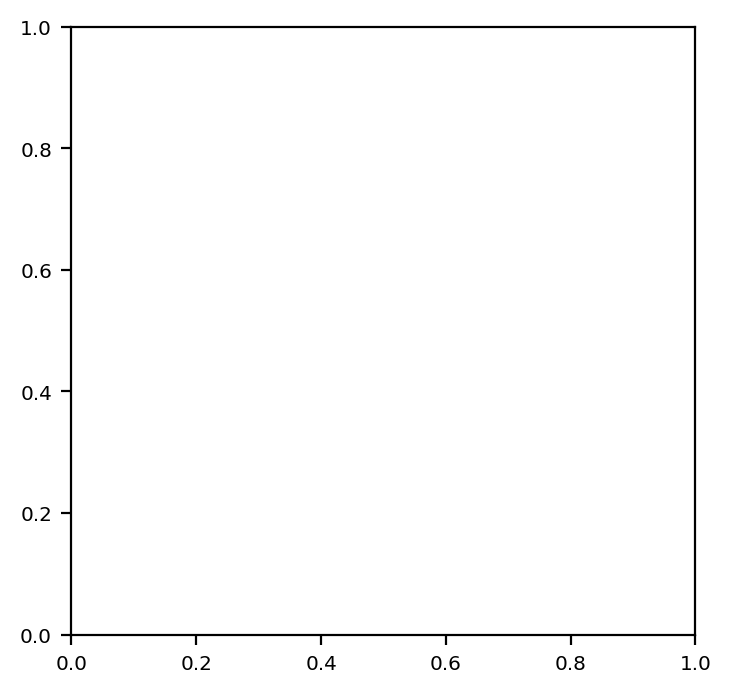

In [5]:
fig, _ = dyn.pl.scatters_interactive(
    adata, basis='umap', color=celltype_key, plot_method='plotly', save_show_or_return='return'
)
fig.update_layout(width=700, height=550)
show_plotly(fig)

## 5. 3D velocity vectors — `cell_wise_vectors_3d`

`dyn.pl.cell_wise_vectors_3d` draws a velocity arrow per cell. With thousands of cells the default arrows are tiny and overlap into noise, so two parameters matter:

- **`cell_inds`** — draw arrows for a random subset of cells (an `int`) instead of all of them.
- **`quiver_3d_kwargs['length']`** — lengthen the arrows; `pointsize` keeps the cell cloud faint so the arrows stand out.

Compare the flow with the 2D streamlines above: the arrows run from the Ductal/Ngn3 progenitors toward the endocrine fates, the same differentiation direction. Change the view with `elev` / `azim`.

|-----> X shape: (3696, 3) V shape: (3696, 3)


|-----------> plotting with basis key=X_umap


|-----------> skip filtering clusters by stack threshold when stacking color because it is not a numeric type


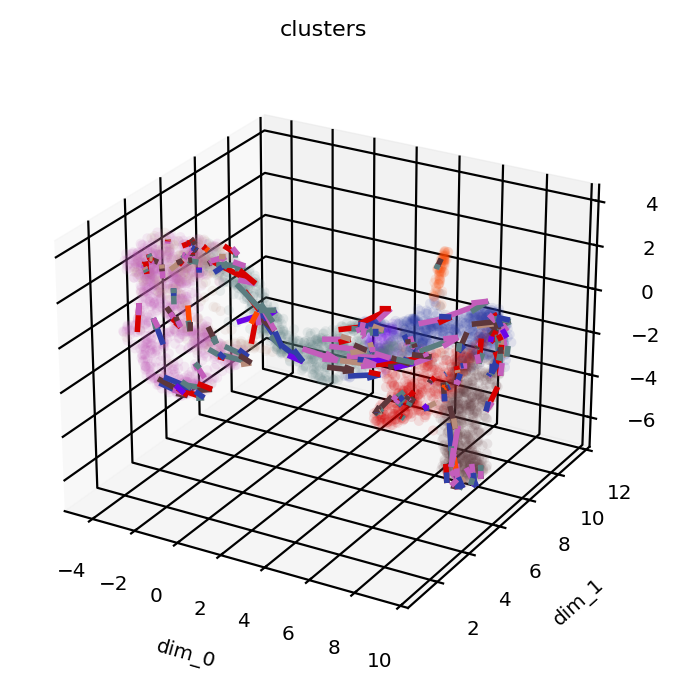

In [6]:
quiver_kwargs = {
    'linewidth': 2.0, 'edgecolors': 'white', 'alpha': 1,
    'length': 35, 'arrow_length_ratio': 0.4, 'cmap': None,
}

dyn.pl.cell_wise_vectors_3d(
    adata, basis='umap', color=[celltype_key], plot_method='matplotlib',
    cell_inds=120, pointsize=0.05, quiver_3d_kwargs=quiver_kwargs,
    elev=25, azim=-60,
)

|-----> X shape: (3696, 3) V shape: (3696, 3)


|-----------> plotting with basis key=X_umap


|-----------> skip filtering clusters by stack threshold when stacking color because it is not a numeric type


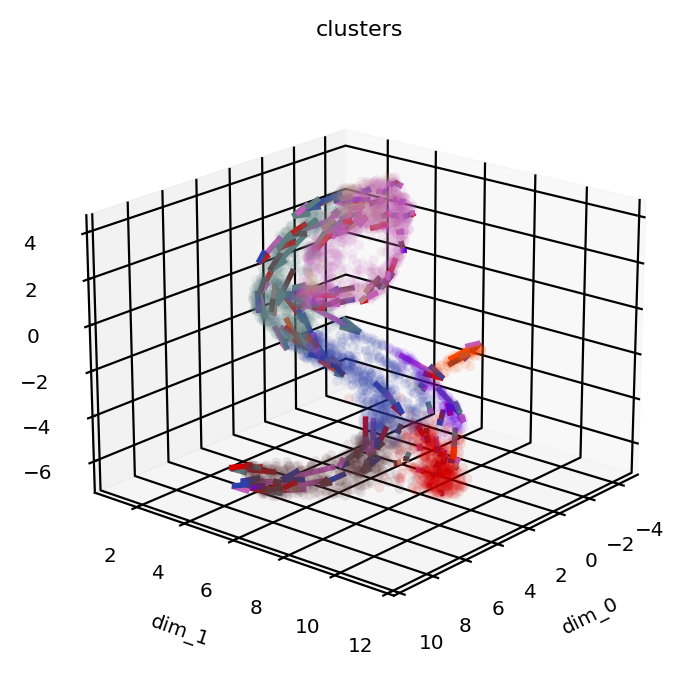

In [7]:
# another viewing angle
dyn.pl.cell_wise_vectors_3d(
    adata, basis='umap', color=[celltype_key], plot_method='matplotlib',
    cell_inds=120, pointsize=0.05, quiver_3d_kwargs=quiver_kwargs,
    elev=20, azim=40,
)

## 6. 3D vector-field topography — `topography_3D`

After reconstructing a continuous vector field in 3D (`dyn.vf.VectorField`, `dims=3`) and identifying its fixed points (`dyn.vf.topography`), `dyn.pl.topography_3D` overlays the topology on the 3D embedding.

|-----> VectorField reconstruction begins...


|-----> Retrieve X and V based on basis: UMAP. 
        Vector field will be learned in the UMAP space.


|-----> Generating high dimensional grids and convert into a row matrix.


|-----> Learning vector field with method: sparsevfc.


|-----> [SparseVFC] begins...


...

|-----------> method kd_tree selected



╭─ SUMMARY: topography ──────────────────────────────────────────────╮
│  Duration: 0.068s                                                  │
│  Shape:    3,696 x 27,998 (Unchanged)                              │
│                                                                    │
│  CHANGES DETECTED                                                  │
│  ────────────────                                                  │
╰────────────────────────────────────────────────────────────────────╯
|-----------> plotting with basis key=X_umap


|-----------> skip filtering clusters by stack threshold when stacking color because it is not a numeric type



╭─ EXPLANATION: FIXED POINTS ────────────────────────────────────────╮
│  What it measures:
│  Fixed points are steady states of the dynamical system where dx/dt = 0.│
│  Full circles are stable/unstable fixed points; half-circles are saddle points.│
│                                                                    │
│  Interpreting values:
│  ● Absorbing / attractors (black, filled): Stable terminal cell    │
│    types — all trajectories                                        │
│    converge here (e.g.,                                            │
│    melanophore, iridophore,                                        │
│    xanthophore, unknown                                            │
│    terminal states)                                                │
│  ● Emitting / repellers (red, filled): Progenitor/source states —  │
│    cells spontaneously                                             │
│    differentiate outward from                                      │
│    these poi

<Axes3D: title={'center': 'clusters'}, xlabel='umap_1', ylabel='umap_2', zlabel='umap_3'>

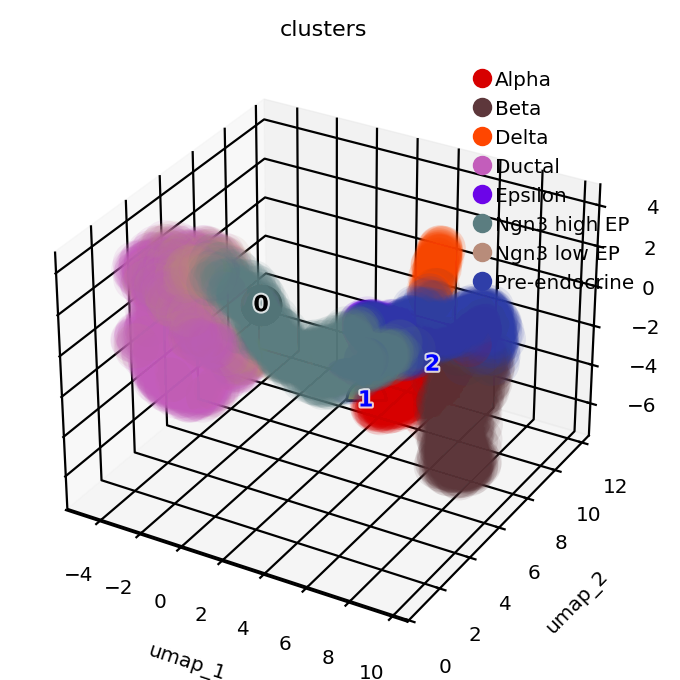

In [8]:
dyn.vf.VectorField(adata, basis='umap', dims=3)
dyn.vf.topography(adata, basis='umap', n=10)

dyn.pl.topography_3D(
    adata, basis='umap', color=[celltype_key], plot_method='matplotlib', save_show_or_return='return'
)

## 7. PyVista, streamtubes, and animation

These tools open interactive PyVista windows or write animation files, so they are best run locally rather than inside a static notebook.

**Interactive PyVista renderers** (rotatable windows):

```python
dyn.pl.scatters_interactive(adata, basis='umap', color=celltype_key, plot_method='pv')
dyn.pl.cell_wise_vectors_3d(adata, basis='umap', color=[celltype_key], plot_method='pv')
dyn.pl.topography_3D(adata, basis='umap', color=[celltype_key], plot_method='pv')
```

**Fate streamtubes** (`plot_3d_streamtube`, Plotly) — visualize fate trajectories grouped by a key, starting from an initial group:

```python
dyn.pl.plot_3d_streamtube(
    adata, color=celltype_key, layer='X', group=celltype_key,
    init_group='Ductal', basis='umap',
)
```

**3D fate animation** (`dyn.mv.PyvistaAnim`) — animate cell-fate commitment after running fate prediction:

```python
dyn.pd.fate(adata, basis='umap', init_cells=adata.obs_names[:50])
anim = dyn.mv.PyvistaAnim(adata, basis='umap', filename='fate_animation.gif')
anim.animate()
```


## Summary

- Build a 3-component embedding (`reduceDimension(..., n_components=3)`) and project velocities (`cell_velocities`).
- The 3D velocity arrows follow the **same differentiation direction** as the trusted 2D streamlines (Ductal → Ngn3 → Pre-endocrine → endocrine).
- **Static / inline:** `cell_wise_vectors_3d`, `topography_3D` (matplotlib), `scatters_interactive` (Plotly).
- **Interactive locally:** the same functions with `plot_method='pv'` (PyVista), `plot_3d_streamtube` (Plotly), and `dyn.mv.PyvistaAnim` (animation).
